https://machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose

Importing plotly failed. Interactive plots will not work.


In [3]:

# load the car sales dataset
#from pandas import read_csv
# load data
#path = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv'
#df = read_csv(path, header=0)

df = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/PROJECT/RoadTrafficCollisions/df_ts_1.xlsx")
df.drop(columns = 'Unnamed: 0', inplace =True)
# summarize shape
print(df.shape)
# show first few rows
print(df.head())


(4017, 20)
        Date  Tmax °C  Tmin °C  Daily Tmean °C Daily range degC Grass min °C  \
0 2015-01-01     13.5      2.6             8.1             10.9            0   
1 2015-01-02      9.2      5.9             7.6              3.3          0.3   
2 2015-01-03      4.9      3.0             4.0              1.9         -4.5   
3 2015-01-04      7.0     -1.5             2.8              8.5           -6   
4 2015-01-05      9.8     -0.8             4.5             10.6         -0.3   

   Air frost 0/1  Ground frost 0/1  Max ≥ 25.0°C  Max ≥ 30.0°C  Min ≥ 15.0 °C  \
0              0               0.0             0             0              0   
1              0               0.0             0             0              0   
2              0               1.0             0             0              0   
3              1               1.0             0             0              0   
4              1               1.0             0             0              0   

   Max < 0 °C Rainfal

In [4]:
print(df['Date'].head(2))
print('.  .... ..   ....')
print('.  .... ..   ....')
print(df['Date'].tail(2))

0   2015-01-01
1   2015-01-02
Name: Date, dtype: datetime64[us]
.  .... ..   ....
.  .... ..   ....
4015   2025-12-29
4016   2025-12-30
Name: Date, dtype: datetime64[us]


<Axes: >

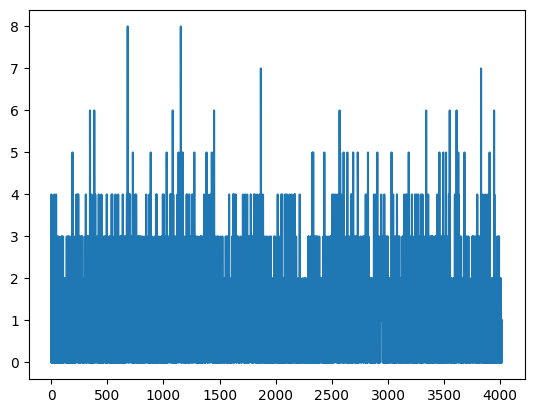

In [5]:
# plot the time series
df['Incident_Count'].plot()


In [6]:
...
# prepare expected column names
#df = df[['Date','Incident_Count']]

df.rename(columns={'Date': 'ds' }, inplace = True)
df.rename(columns={'Incident_Count': 'y' }, inplace = True)
df['ds']= pd.to_datetime(df['ds'])


df = df[['ds', 'y']]
df['ds']= pd.to_datetime(df['ds'])
df.head(2)
df.head(2)

,ds,y
0,2015-01-01,3
1,2015-01-02,0


Make an In-Sample Forecast

It can be useful to make a forecast on historical data.

That is, we can make a forecast on data used as input to train the model. Ideally, the model has seen the data before and would make a perfect prediction.

Nevertheless, this is not the case as the model tries to generalize across all cases in the data.

This is called making an in-sample (in training set sample) forecast and reviewing the results can give insight into how good the model is. That is, how well it learned the training data.

A forecast is made by calling the predict() function and passing a DataFrame that contains one column named ‘ds‘ and rows with date-times for all the intervals to be predicted.

There are many ways to create this “forecast” DataFrame. In this case, we will loop over one year of dates, e.g. the last 12 months in the dataset, and create a string for each month. We will then convert the list of dates into a DataFrame and convert the string values into date-time objects.

In [7]:
df.shape[0]

4017

In [8]:
import pandas as pd

# Generate the range (inclusive by default)
date_list = pd.date_range(start="2015-01-01", end="2025-12-30", freq="D")

# Convert to a standard Python list of timestamps
date_list = date_list.tolist()
date_list = pd.DataFrame(date_list)
print(f"Total dates generated: {len(date_list)}")
date_list

Total dates generated: 4017


,0
0,2015-01-01
1,2015-01-02
2,2015-01-03
3,2015-01-04
4,2015-01-05
...,...
4012,2025-12-26
4013,2025-12-27
4014,2025-12-28
4015,2025-12-29


In [28]:
future_dates = pd.date_range(start="2024-01-01", end="2026-01-01", freq="D")

# Convert to a standard Python list of timestamps
future_date_list = future_dates.tolist()

#print(f"Total dates generated: {len(future_date_list)}")

future_date_list = pd.DataFrame(future_date_list)
#future_date_list= pd.to_datetime(future_date_list)
future_date_list

,0
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05
...,...
727,2025-12-28
728,2025-12-29
729,2025-12-30
730,2025-12-31


In [29]:
# define the model
model = Prophet()
# fit the model
model.fit(df)

18:29:29 - cmdstanpy - INFO - Chain [1] start processing
18:29:30 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
future_date_list = pd.DataFrame(future_date_list)
future_date_list.columns = ['ds']
future_date_list['ds']= pd.to_datetime(future_date_list['ds'])
future_date_list

,ds
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05
...,...
727,2025-12-28
728,2025-12-29
729,2025-12-30
730,2025-12-31


In [31]:
forecast = model.predict(future_date_list) 
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2024-01-01,1.160783,-0.434798,2.365282,1.160783,1.160783,-0.201057,-0.201057,-0.201057,-0.028845,-0.028845,-0.028845,-0.172212,-0.172212,-0.172212,0.0,0.0,0.0,0.959725
1,2024-01-02,1.160725,-0.614015,2.408846,1.160725,1.160725,-0.267799,-0.267799,-0.267799,-0.089827,-0.089827,-0.089827,-0.177973,-0.177973,-0.177973,0.0,0.0,0.0,0.892925
2,2024-01-03,1.160667,-0.513687,2.411409,1.160667,1.160667,-0.171027,-0.171027,-0.171027,0.007757,0.007757,0.007757,-0.178784,-0.178784,-0.178784,0.0,0.0,0.0,0.989640
3,2024-01-04,1.160609,-0.441634,2.445338,1.160609,1.160609,-0.165426,-0.165426,-0.165426,0.009375,0.009375,0.009375,-0.174801,-0.174801,-0.174801,0.0,0.0,0.0,0.995182
4,2024-01-05,1.160551,-0.294047,2.649314,1.160551,1.160551,0.047100,0.047100,0.047100,0.213368,0.213368,0.213368,-0.166268,-0.166268,-0.166268,0.0,0.0,0.0,1.207651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,2025-12-28,1.118606,-0.506389,2.419054,1.118606,1.118606,-0.171639,-0.171639,-0.171639,-0.058513,-0.058513,-0.058513,-0.113126,-0.113126,-0.113126,0.0,0.0,0.0,0.946967
728,2025-12-29,1.118548,-0.497954,2.264518,1.118548,1.118548,-0.164869,-0.164869,-0.164869,-0.028845,-0.028845,-0.028845,-0.136024,-0.136024,-0.136024,0.0,0.0,0.0,0.953679
729,2025-12-30,1.118490,-0.593948,2.395629,1.118490,1.118490,-0.244021,-0.244021,-0.244021,-0.089827,-0.089827,-0.089827,-0.154194,-0.154194,-0.154194,0.0,0.0,0.0,0.874469
730,2025-12-31,1.118432,-0.450237,2.393931,1.118432,1.118432,-0.159697,-0.159697,-0.159697,0.007757,0.007757,0.007757,-0.167455,-0.167455,-0.167455,0.0,0.0,0.0,0.958734


In [32]:
...
# summarize the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

          ds      yhat  yhat_lower  yhat_upper
0 2024-01-01  0.959725   -0.434798    2.365282
1 2024-01-02  0.892925   -0.614015    2.408846
2 2024-01-03  0.989640   -0.513687    2.411409
3 2024-01-04  0.995182   -0.441634    2.445338
4 2024-01-05  1.207651   -0.294047    2.649314


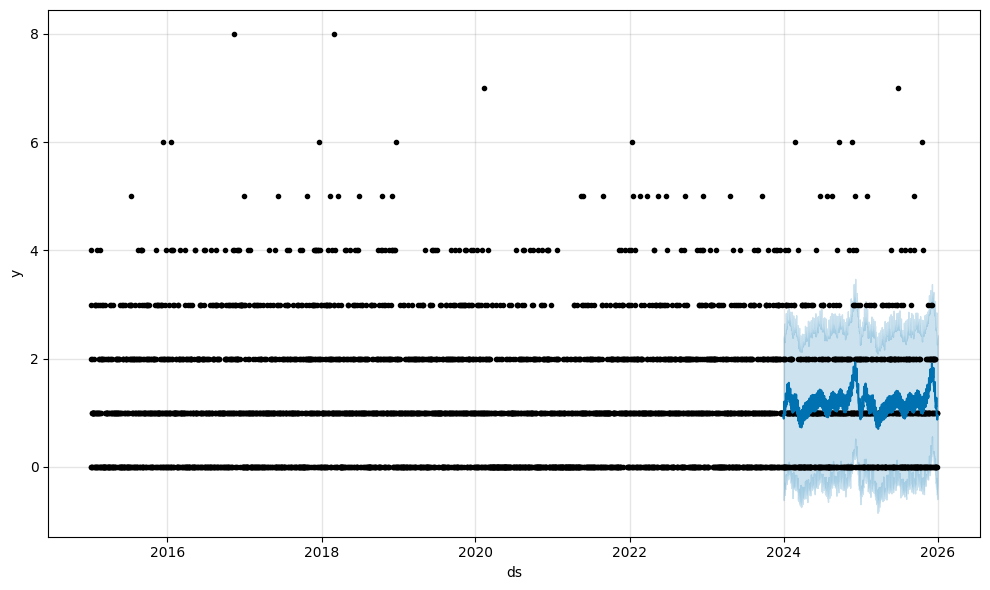

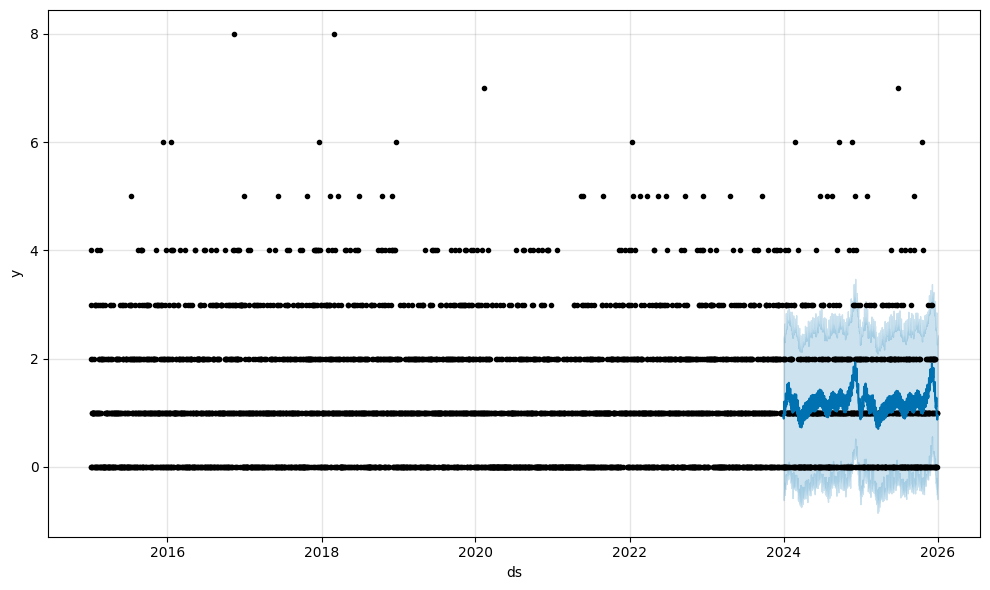

In [33]:

model.plot(forecast)


Make an Out-of-Sample Forecast
In practice, we really want a forecast model to make a prediction beyond the training data.

This is called an out-of-sample forecast.

We can achieve this in the same way as an in-sample forecast and simply specify a different forecast period.

In this case, a period beyond the end of the training dataset, starting 1969-01.

Manually Evaluate Forecast Model
It is critical to develop an objective estimate of a forecast model’s performance.

This can be achieved by holding some data back from the model, such as the last 12 months. Then, fitting the model on the first portion of the data, using it to make predictions on the held-pack portion, and calculating an error measure, such as the mean absolute error across the forecasts. E.g. a simulated out-of-sample forecast.

The score gives an estimate of how well we might expect the model to perform on average when making an out-of-sample forecast.

We can do this with the samples data by creating a new DataFrame for training with the last 12 months removed.

In [34]:

...
# create test dataset, remove last 12 months
train = df.drop(df.index[-12:])
print(train.tail())

             ds  y
4000 2025-12-14  0
4001 2025-12-15  1
4002 2025-12-16  2
4003 2025-12-17  2
4004 2025-12-18  0


In [35]:
# A forecast can then be made on the last 12 months of date-times.

# We can then retrieve the forecast values and the expected values from the original dataset 
# and calculate a mean absolute error metric using the scikit-learn library.

In [38]:
# calculate MAE between expected and predicted values for december

# mae = mean_absolute_error(results["y"], results["yhat"])
# rmse = np.sqrt(mean_squared_error(results["y"], results["yhat"]))

#y_true = df['y'][-12:].values
y_true = df['y'].values
y_pred = forecast['yhat'].values
#mae = mean_absolute_error(y_true, y_pred)
#print('MAE: %.3f' % mae)
y_true, y_pred

(array([3, 0, 0, ..., 0, 1, 1], shape=(4017,)),
 array([0.95972511, 0.89292547, 0.98963962, 0.99518214, 1.20765053,
        0.95366023, 0.96496582, 1.01446644, 0.97611183, 1.09853454,
        1.12658793, 1.35798159, 1.11902467, 1.14125349, 1.19744127,
        1.16150616, 1.28214328, 1.30436023, 1.52610788, 1.274017  ,
        1.28001729, 1.31733683, 1.26039854, 1.35843944, 1.3570327 ,
        1.55470445, 1.27865652, 1.26137161, 1.27659977, 1.19924262,
        1.27896173, 1.26169126, 1.44624706, 1.16004364, 1.1356956 ,
        1.14700242, 1.06883317, 1.15073739, 1.13846228, 1.33056818,
        1.05415354, 1.04146579, 1.06589679, 1.00187898, 1.09850835,
        1.10107389, 1.30768526, 1.04500957, 1.04489341, 1.08036827,
        1.02555571, 1.12929765, 1.13669166, 1.3457227 , 1.08300207,
        1.08038981, 1.11099865, 1.0490959 , 1.14372885, 1.1402536 ,
        1.33695913, 1.06079742, 1.04399624, 1.06005293, 0.98362582,
        1.06414921, 1.04735208, 1.23187248, 0.94497898, 0.91917559,


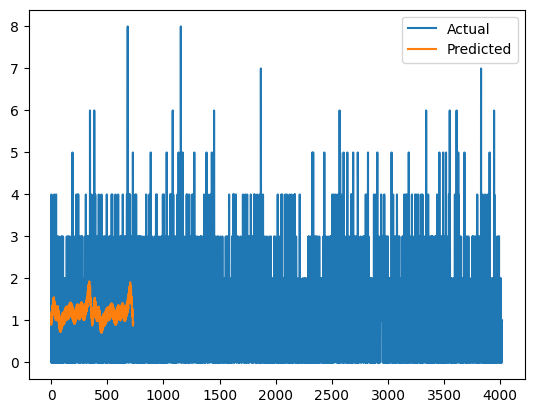

In [39]:
# plot expected vs actual
plt.plot(y_true, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

Make an Out-of-Sample Forecast In practice, we really want a forecast model to make a prediction beyond the training data.

This is called an out-of-sample forecast.

We can achieve this in the same way as an in-sample forecast and simply specify a different forecast period.

In this case, a period beyond the end of the training dataset, starting 2027-01.

          ds      yhat  yhat_lower  yhat_upper
0 2024-01-01  0.959725   -0.574695    2.321845
1 2024-01-02  0.892925   -0.520594    2.351343
2 2024-01-03  0.989640   -0.506343    2.454124
3 2024-01-04  0.995182   -0.433508    2.337722
4 2024-01-05  1.207651   -0.308100    2.636365


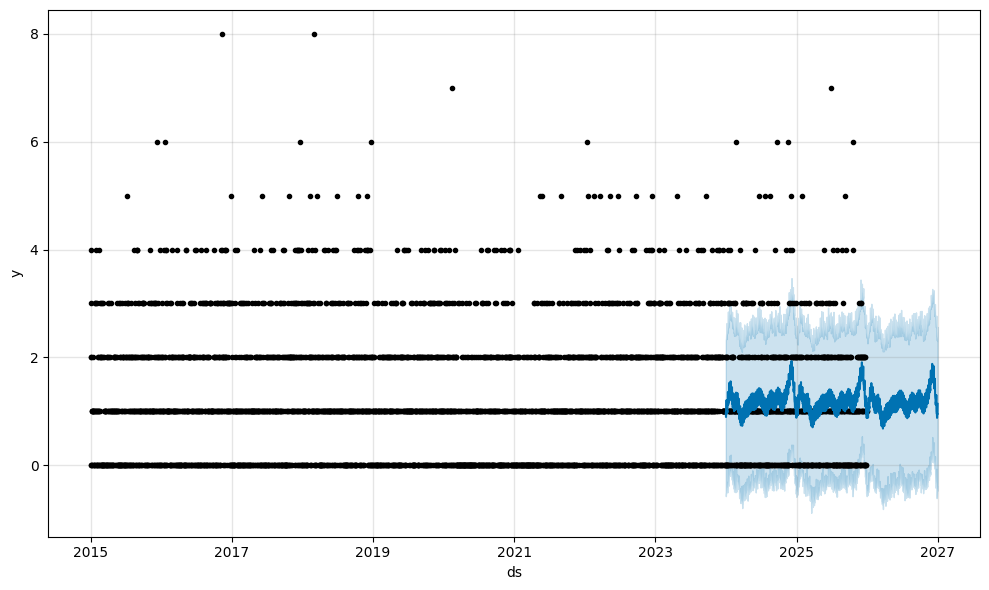

In [44]:
# define the period for which we want a prediction
future_dates = pd.date_range(start="2024-01-01", end="2027-01-01", freq="D")

# Convert to a standard Python list of timestamps
future = future_dates.tolist()

#print(f"Total dates generated: {len(future_date_list)}")

future = pd.DataFrame(future)

#future = DataFrame(future)
future.columns = ['ds']
future['ds']= pd.to_datetime(future['ds'])
# use the model to make a forecast
forecast = model.predict(future)
# summarize the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())
# plot forecast
model.plot(forecast)
plt.show()